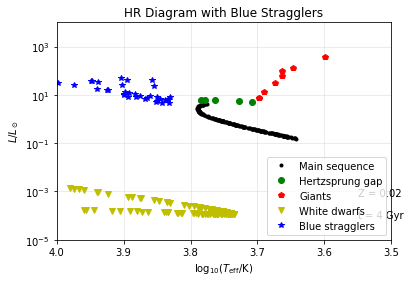

In [3]:
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


"""
HR Diagram with Blue Stragglers

Simulates a stellar population in isolation and overlays blue stragglers
to illustrate how they appear beyond the main-sequence turnoff.

Author: Emilie Desrochers Karlsson
"""


# -------------------------------
# CONSTANTS
# -------------------------------

SB = 5.67e-8
SOLAR_L = 3.828e26
SOLAR_R = 6.957e8

Z = 0.02
T_MAX = 4000  # Myr


# -------------------------------
# BSE INTERFACE
# -------------------------------

def run_bse(m1, m2, t, period, ecc, z):
   with open("binary.in", "r") as f:
       lines = f.readlines()

   lines[0] = "{} {} {} {} {} {} {} {}\n".format(
       m1, m2, t, period, 1, 1, z, ecc
   )

   with open("binary.in", "w") as f:
       f.writelines(lines)

   os.system("./bse")

   try:
       data = np.loadtxt("binary.dat")
       return np.stack(data, axis=-1)
   except ValueError:
       return None


# -------------------------------
# STELLAR PROPERTIES
# -------------------------------

def compute_teff(L, R):
   return (L / (4 * np.pi * SB * R**2))**(1/4)


def evolve_single_star(mass, t, z):
   """
   Evolves a single star and returns luminosity, radius, type.
   """
   data = run_bse(mass, 0, t, 0, 0, z)

   if data is None:
       return None

   time = data[0]
   logL = data[11]
   logR = data[7]
   kw = data[1]

   i = -2

   if time[i] != t:
       return None

   L = 10**logL[i]
   R = 10**logR[i]
   stellar_type = kw[i]

   return L, R, stellar_type


# -------------------------------
# LOAD BLUE STRAGGLERS
# -------------------------------

def load_blue_stragglers(filename):
   data = np.loadtxt(filename)
   data = np.stack(data, axis=-1)

   L = data[0]
   R = data[1]

   teff = compute_teff(SOLAR_L * L, SOLAR_R * R)

   # filter hot (BS region)
   mask = np.log10(teff) > 3.83

   return teff[mask], L[mask]


# -------------------------------
# POPULATION SAMPLING
# -------------------------------

def sample_mass():
   return (random.random() * (100**(-1.3) - 0.5**(-1.3)) + 0.5**(-1.3))**(1 / -1.3)


def generate_population(n_stars, t, z):
   """
   Generates stellar population and classifies types.
   """
   MS, HG, giants, WD = [], [], [], []

   for _ in range(n_stars):
       mass = sample_mass()
       result = evolve_single_star(mass, t, z)

       if result is None:
           continue

       L, R, stellar_type = result

       L_si = SOLAR_L * L
       R_si = SOLAR_R * R
       teff = compute_teff(L_si, R_si)

       entry = (np.log10(teff), L)

       if stellar_type == 1:
           MS.append(entry)
       elif stellar_type == 2:
           HG.append(entry)
       elif stellar_type in [3, 4, 5, 6]:
           giants.append(entry)
       elif stellar_type in [10, 11, 12]:
           WD.append(entry)

   return MS, HG, giants, WD


# -------------------------------
# PLOTTING
# -------------------------------

def plot_hr_diagram(MS, HG, giants, WD, BS_teff, BS_L):
   plt.figure()
   ax = plt.gca()
   ax.set_yscale('log')

   def unpack(data):
       if not data:
           return [], []
       x, y = zip(*data)
       return x, y

   MS_x, MS_y = unpack(MS)
   HG_x, HG_y = unpack(HG)
   G_x, G_y = unpack(giants)
   WD_x, WD_y = unpack(WD)

   plt.plot(MS_x, MS_y, 'k.', label='Main sequence')
   if HG:
       plt.plot(HG_x, HG_y, 'go', label='Hertzsprung gap')
   if giants:
       plt.plot(G_x, G_y, 'rp', label='Giants')
   if WD:
       plt.plot(WD_x, WD_y, 'yv', label='White dwarfs')

   # Blue stragglers
   plt.plot(np.log10(BS_teff), BS_L, 'b*', label='Blue stragglers')

   plt.xlabel(r'$\log_{10}(T_{\mathrm{eff}} / \mathrm{K})$')
   plt.ylabel(r'$L / L_\odot$')

   plt.xlim(4, 3.5)
   plt.ylim(1e-5, 1e4)

   plt.legend()
   plt.grid(alpha=0.3)

   plt.text(0.9, 0.2, 'Z = 0.02', transform=ax.transAxes)
   plt.text(0.9, 0.1, 't = 4 Gyr', transform=ax.transAxes)

   plt.title('HR Diagram with Blue Stragglers')

   plt.show()


# -------------------------------
# MAIN SIMULATION
# -------------------------------

if __name__ == "__main__":

   # Load BS data
   BS_teff, BS_L = load_blue_stragglers("t_4000_Z_solar")

   # Generate population
   MS, HG, giants, WD = generate_population(600, T_MAX, Z)

   # Plot
   plot_hr_diagram(MS, HG, giants, WD, BS_teff, BS_L)